# RamanBench — Quick Start

This notebook introduces the RamanBench ecosystem and shows the fastest path to exploring results.

## Ecosystem

| Resource                       | Link                                                                                               |
|--------------------------------|----------------------------------------------------------------------------------------------------|
| **raman-data** (datasets)      | [GitHub](https://github.com/ml-lab-htw/raman_data) · [PyPI](https://pypi.org/project/raman-data/)  |
| **raman-bench** (this package) | [GitHub](https://github.com/ml-lab-htw/RamanBench) · [PyPI](https://pypi.org/project/raman-bench/) |
| **Live Leaderboard**           | [HuggingFace Space](https://huggingface.co/spaces/HTW-KI-Werkstatt/RamanBench)                           |
| **Paper**                      | [arXiv TBD](https://arxiv.org/abs/TBD)                                                             |

In [1]:
# Install if not already installed
# !pip install raman-bench

## 1. Load a Raman dataset

In [2]:
from raman_data import raman_data

# Load a regression dataset (amino acid concentrations)
dataset = raman_data('amino_acids_glycine')

print(f'Dataset: {dataset.name}')
print(f'Spectra shape: {dataset.spectra.shape}  (samples × wavenumbers)')
print(f'Targets shape: {dataset.targets.shape}')
print(f'Target names: {dataset.target_names}')
print(f'Spectral range: {dataset.raman_shifts.min():.0f}–{dataset.raman_shifts.max():.0f} cm⁻¹')

Dataset: Amino Acid LC (Glycine)
Spectra shape: (90, 1024)  (samples × wavenumbers)
Targets shape: (90,)
Target names: ['G']
Spectral range: 326–2035 cm⁻¹


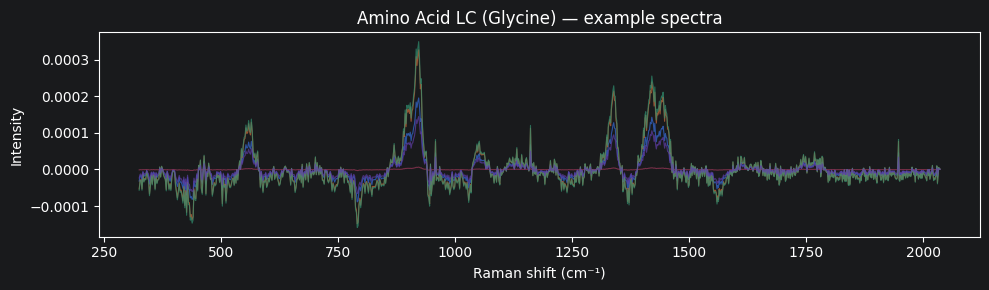

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
for i in range(min(5, len(dataset.spectra))):
    ax.plot(dataset.raman_shifts, dataset.spectra[i], alpha=0.7, linewidth=0.8)
ax.set_xlabel('Raman shift (cm⁻¹)')
ax.set_ylabel('Intensity')
ax.set_title(f'{dataset.name} — example spectra')
plt.tight_layout()
plt.show()

## 2. Browse the precomputed leaderboard

In [4]:
from raman_bench import Leaderboard

lb = Leaderboard.from_precomputed()
lb.rank()

2026-04-27 22:33:48,484 INFO raman_bench.leaderboard:from_precomputed:136: Loaded precomputed leaderboard: 10449 regression rows, 1827 classification rows


,Rank,model_id,Model,Category,Elo,Score,Avg Rank,Improvability,Train Time s,Infer. s/1K
0,1,AUTOGLUON,"AutoGluon 1.5 (extreme, 4h)",AutoML,1558.0,0.7974,3.9,20.3,1776.3,220.7
1,2,REALTABPFN-V2.5,TabPFN v2.5,Tabular Foundation,1529.0,0.7594,4.3,24.1,89.6,100.8
2,3,TABICL,TabICL,Tabular Foundation,1443.0,0.6430,5.7,35.7,39.9,130.3
3,4,REALTABPFN-V2,TabPFN v2,Tabular Foundation,1402.0,0.6397,6.3,36.0,77.6,146.4
4,5,MITRA,MITRA,Tabular Foundation,1312.0,0.4923,8.1,50.8,827.4,626.5
5,6,REZERONET,ReZeroNet,Raman-Specific,1133.0,0.3023,11.9,69.8,44.6,23.1
6,7,TABDPT,TabDPT,Tabular Foundation,1136.0,0.2920,11.9,70.8,12.3,80.2
7,8,LR,Logistic Reg.,Traditional ML,1002.0,0.2279,15.1,77.2,37.2,41.2
8,9,REALMLP,RealMLP,Deep Learning,1111.0,0.2198,13.1,78.0,1935.5,71.1
9,10,PLS,PLS,Traditional ML,1004.0,0.2180,15.4,78.2,29.7,19.2


,Rank,model_id,Model,Category,Elo,Score,Avg Rank,Improvability,Train Time s,Infer. s/1K
0,1,AUTOGLUON,"AutoGluon 1.5 (extreme, 4h)",AutoML,1558.0,0.8092,3.7,19.1,1776.3,220.7
1,2,REALTABPFN-V2.5,TabPFN v2.5,Tabular Foundation,1529.0,0.7745,3.9,22.5,89.6,100.8
2,3,REALTABPFN-V2,TabPFN v2,Tabular Foundation,1402.0,0.6723,5.7,32.8,77.6,146.4
3,4,TABICL,TabICL,Tabular Foundation,1443.0,0.6480,5.4,35.2,39.9,130.3
4,5,MITRA,MITRA,Tabular Foundation,1312.0,0.5160,7.3,48.4,827.4,626.5
5,6,TABDPT,TabDPT,Tabular Foundation,1136.0,0.2863,11.7,71.4,12.3,80.2
6,7,REZERONET,ReZeroNet,Raman-Specific,1133.0,0.2637,12.5,73.6,44.6,23.1
7,8,REALMLP,RealMLP,Deep Learning,1111.0,0.2226,12.8,77.7,1935.5,71.1
8,9,PLS,PLS,Traditional ML,1004.0,0.2206,14.8,77.9,29.7,19.2
9,10,LR,Logistic Reg.,Traditional ML,1002.0,0.2093,15.3,79.1,37.2,41.2


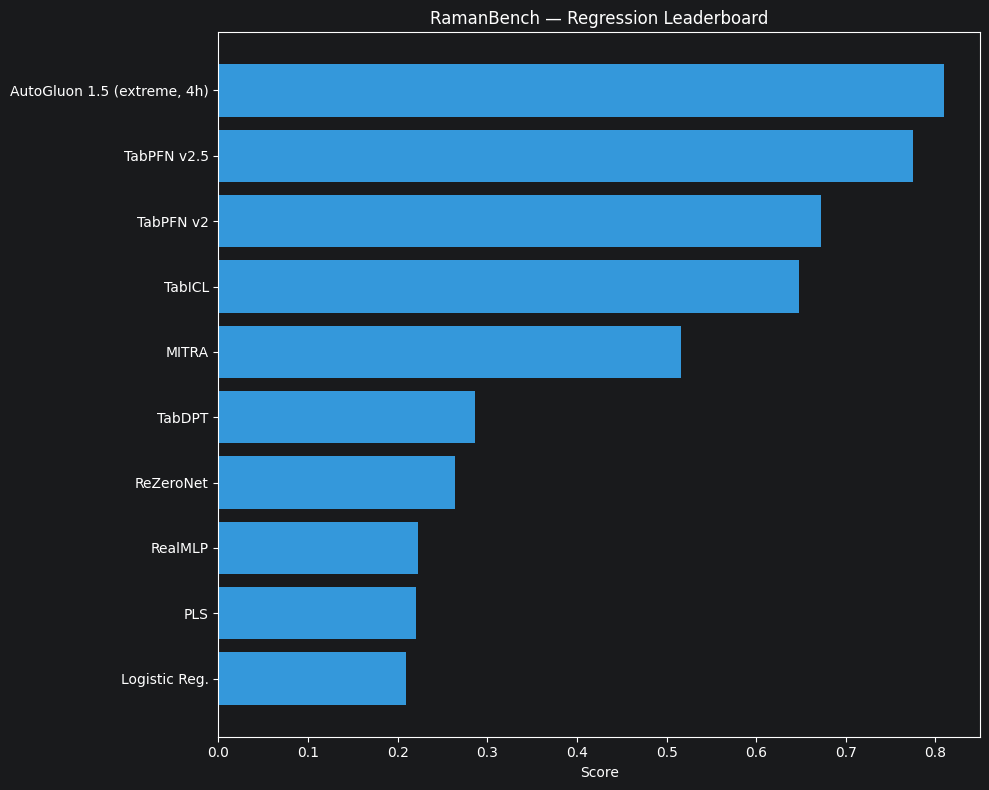

In [5]:
# Regression-only ranking — table
display(lb.rank(task="regression").head(10))

# Regression-only ranking — chart
fig = lb.plot(task="regression", n_top=10)
plt.show()


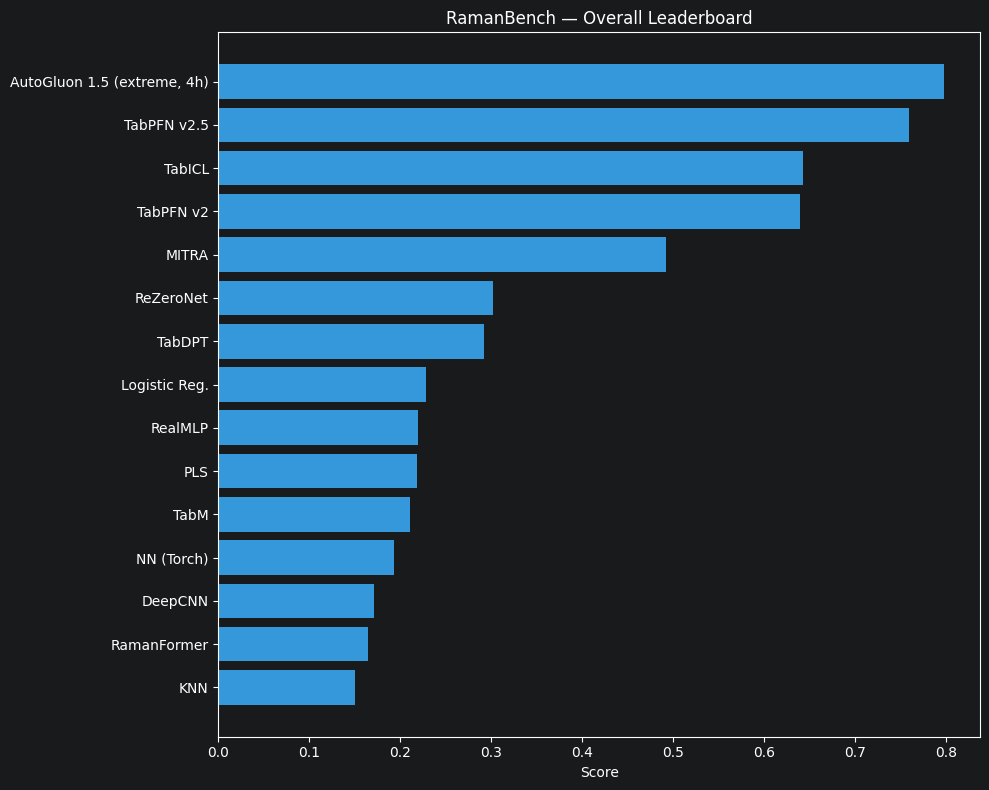

In [6]:
fig = lb.plot(task='overall', n_top=15)
plt.show()

## Next steps

- **`02_benchmark_new_model.ipynb`** — evaluate your own model
- **`03_explore_results.ipynb`** — deep dive into per-dataset metrics
- **`04_contribute_dataset.ipynb`** — contribute a new dataset
- **[Live Leaderboard](https://huggingface.co/spaces/HTW-KI-Werkstatt/RamanBench)** — interactive results explorer